In [1]:
# ============================
# CELL 1: COMMON DEFINITIONS
# ============================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
from google.colab import drive
drive.mount('/content/drive')
# ===========================
# Reproducibility
# ===========================
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# ==========================
# Device
# ==========================
if torch.cuda.is_available():
  device = 'cuda'
  print(torch.cuda.get_device_name(0))
else:
  device = 'cpu'
print('using device:', device)
# ==========================
# PINN Model
# ==========================
LAYERS = 8
NEURONS = 256
class PINN(nn.Module):
  def __init__(self, layers=LAYERS, neurons=NEURONS):
    super().__init__()
    net = [nn.Linear(3, neurons), nn.Tanh()]
    for _ in range(layers - 1):
      net += [nn.Linear(neurons, neurons), nn.Tanh()]
    net += [nn.Linear(neurons, 1)]
    self.net = nn.Sequential(*net)
    self.initialize_weights()

  def initialize_weights(self):
    for m in self.modules():
      if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
          nn.init.zeros_(m.bias)
  def forward(self, x):
    return self.net(x)
model = PINN().to(device)
# =========================
# Hyperparameters
# =========================
N_f = 10000
N_i = 5000
T_final = 5.0
adam_epochs = 20000
lbfgs_epochs = 500
w_pde, w_ic , w_eik = 1.0, 10.0, 0.001
# =========================
# Velocity Field
# =========================
def velocity_field(x, y):
  u = torch.zeros_like(x)
  v = 0.1 * torch.ones_like(y)
  return u, v
# =========================
# Initial Condition
# =========================
def initial_condition(x, y):
  xc, yc, r = 0.5, 0.2, 0.15
  return torch.sqrt((x - xc)**2 + (y - yc)**2) - r
# =========================
# Exact Solution
# =========================
def exact_solution(x, y, t):
  xc, yc, r = 0.5, 0.2, 0.15
  return torch.sqrt((x - xc)**2 + (y - yc - 0.1 * t)**2) - r
# =========================
# Sample Points
# =========================
torch.manual_seed(100)
torch.cuda.manual_seed(100)
X_f = torch.rand(N_f, 3, dtype=torch.float32, device=device)
X_f.requires_grad = True

x_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
y_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
t_i = torch.zeros(N_i, 1, dtype=torch.float32, device=device)
X_i = torch.cat([x_i, y_i, t_i], dim=1)
# =========================
# Loss Function
# ========================
def physics_loss(X_f, X_i):
  # PDE Loss
  phi = model(X_f)
  grad_phi = torch.autograd.grad(phi, X_f, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
  phi_x, phi_y, phi_t = grad_phi[:, 0:1], grad_phi[:, 1:2], grad_phi[:, 2:3]
  u, v = velocity_field(X_f[:, 0:1], X_f[:, 1:2])
  f_pde = phi_t + T_final * (u * phi_x + v * phi_y)
  loss_pde = torch.mean(f_pde**2)
  # Initial Condition Loss
  phi_true = initial_condition(X_i[:, 0:1], X_i[:, 1:2])
  phi_pred = model(X_i)
  loss_ic = torch.mean((phi_true - phi_pred)**2)
  # Eikonal Loss
  norm_phi = torch.sqrt(phi_x**2 + phi_y**2 + 1e-8)
  loss_eik = torch.mean((norm_phi - 1)**2)

  total_loss = w_pde * loss_pde + w_ic * loss_ic + w_eik * loss_eik
  return loss_pde, loss_ic, loss_eik, total_loss

Mounted at /content/drive
Tesla T4
using device: cuda


In [ ]:
# ========================
# Training
# ========================
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer_adam, step_size=1000, gamma=0.9)
start_time = time.time()
history = {'epoch': [], 'total': [], 'pde': [], 'ic': [], 'eik': []}
# Adam optimizer
for epoch in range(adam_epochs):
    optimizer_adam.zero_grad()
    loss_pde, loss_ic, loss_eik, loss = physics_loss(X_f, X_i)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer_adam.step()
    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    history['epoch'].append(epoch)
    history['total'].append(loss.item())
    history['pde'].append(loss_pde.item())
    history['ic'].append(loss_ic.item())
    history['eik'].append(loss_eik.item())

    if epoch % 2000 == 0:
      print(f"Adam Iter {epoch} | total loss {loss.item():.3e} | pde loss {loss_pde.item():.3e} | ic loss {loss_ic.item():.3e} | eik loss {loss_eik.item():.3e} | LR {lr:.3e}")
    elif epoch == adam_epochs - 1:
      print(f"Adam Iter {adam_epochs} | total loss {loss.item():.3e} | pde loss {loss_pde.item():.3e} | ic loss {loss_ic.item():.3e} | eik loss {loss_eik.item():.3e} | LR {lr:.3e}")

# LBFGS training
print("LBFGS Optimizer Starting...")
optimizer_lbfgs = optim.LBFGS(model.parameters(), lr=1.0,  line_search_fn='strong_wolfe')
loss_store = {}
for epoch in range(lbfgs_epochs):
    def closure():
        optimizer_lbfgs.zero_grad()
        loss_pde, loss_ic, loss_eik, loss = physics_loss(X_f, X_i)
        loss.backward()
        loss_store['total'] = loss.item()
        loss_store['pde'] = loss_pde.item()
        loss_store['ic'] = loss_ic.item()
        loss_store['eik'] = loss_eik.item()
        return loss
    optimizer_lbfgs.step(closure)

    history['epoch'].append(adam_epochs + epoch)
    history['total'].append(loss_store['total'])
    history['pde'].append(loss_store['pde'])
    history['ic'].append(loss_store['ic'])
    history['eik'].append(loss_store['eik'])
    if epoch % 200 == 0:
      print(f"LBFGS epoch {epoch} | total loss {loss_store['total']:.3e} | pde loss {loss_store['pde']:.3e} | ic loss {loss_store['ic']:.3e} | eik loss {loss_store['eik']:.3e}")
    elif epoch == lbfgs_epochs - 1:
      print(f"LBFGS epoch {lbfgs_epochs} | total loss {loss_store['total']:.3e} | pde loss {loss_store['pde']:.3e} | ic loss {loss_store['ic']:.3e} | eik loss {loss_store['eik']:.3e}")
end_time = time.time()
total_training_time = (end_time - start_time)/60
print(f"Full training done in {total_training_time:.1f} minutes")

# Save checkpoint
checkpoint_path = '/content/drive/MyDrive/TR_S2_exp02.pth'
torch.save({
    'model_state_dict':           model.state_dict(),
    'optimizer_adam_state_dict':  optimizer_adam.state_dict(),
    'optimizer_lbfgs_state_dict': optimizer_lbfgs.state_dict(),
    'training_time':              f'{total_training_time:.1f} minutes',
    'history':                    history
}, checkpoint_path)
print(f"Saved to {checkpoint_path}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adam Iter 0 | total loss 3.896e+00 | pde loss 1.959e-02 | ic loss 3.876e-01 | eik loss 4.251e-01 | LR 1.000e-03
Adam Iter 2000 | total loss 1.163e-03 | pde loss 4.008e-06 | ic loss 1.110e-04 | eik loss 4.899e-02 | LR 8.100e-04
Adam Iter 4000 | total loss 4.421e-04 | pde loss 1.756e-06 | ic loss 4.126e-05 | eik loss 2.773e-02 | LR 6.561e-04
Adam Iter 6000 | total loss 1.295e-04 | pde loss 8.051e-07 | ic loss 1.144e-05 | eik loss 1.427e-02 | LR 5.314e-04
Adam Iter 8000 | total loss 2.744e-04 | pde loss 6.412e-07 | ic loss 2.621e-05 | eik loss 1.166e-02 | LR 4.305e-04
Adam Iter 10000 | total loss 1.752e-04 | pde loss 3.388e-07 | ic loss 1.638e-05 | eik loss 1.103e-02 | LR 3.487e-04
Adam Iter 12000 | total loss 9.103e-05 | pde loss 2.980e-07 | ic loss 7.959e-06 | eik loss 1.114e-02 | LR 2.824e-04
Adam Iter 14000 | total loss 5.701e-05 | pde loss 3.087e-07 | ic loss 4.742e-06 | eik loss 9.286e-03 | LR 2.288e-04
Adam Iter 16000 | total loss 2.979e-05 | pde loss 1.944e-07 | ic loss 2.207e-06 

In [2]:
# ===========================
# Load Model
# ===========================
checkpoint = torch.load('/content/drive/MyDrive/TR_S2_exp02.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model Loaded Successfully!")

Model Loaded Successfully!


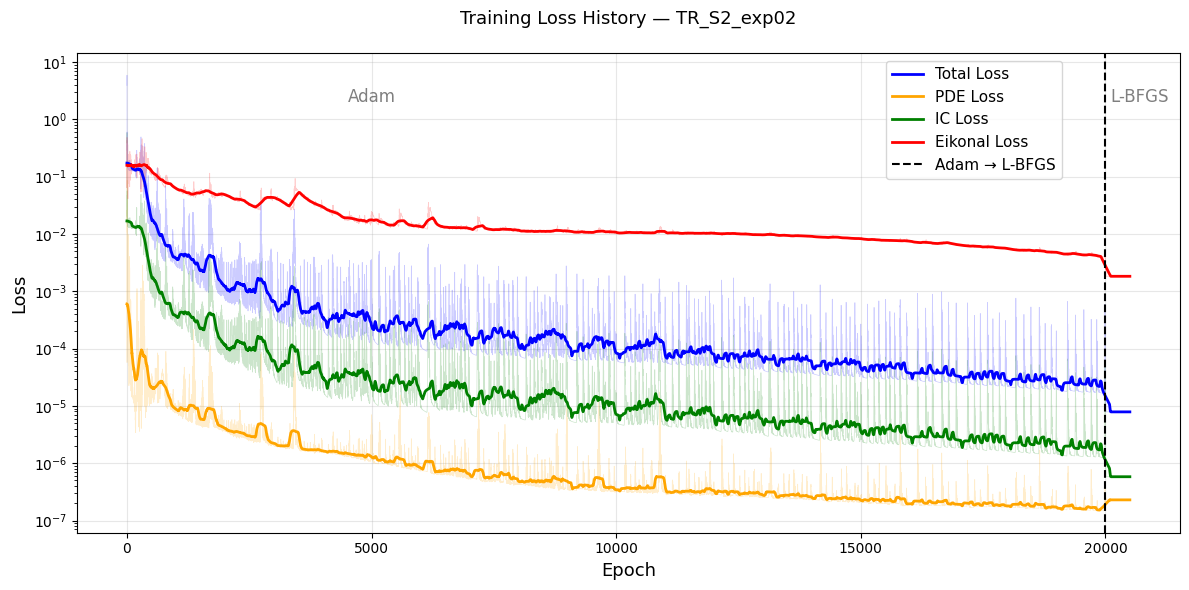

Saved


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import uniform_filter1d

history = checkpoint['history']
epochs = np.array(history['epoch'])
total  = np.array(history['total'])
pde    = np.array(history['pde'])
ic     = np.array(history['ic'])
eik    = np.array(history['eik'])

fig, ax = plt.subplots(figsize=(12, 6))

# Raw losses
colors = {'total': 'blue', 'pde': 'orange', 'ic': 'green', 'eik': 'red'}
ax.semilogy(epochs, total, color=colors['total'], alpha=0.2, linewidth=0.5)
ax.semilogy(epochs, pde,   color=colors['pde'],   alpha=0.2, linewidth=0.5)
ax.semilogy(epochs, ic,    color=colors['ic'],    alpha=0.2, linewidth=0.5)
ax.semilogy(epochs, eik,   color=colors['eik'],   alpha=0.2, linewidth=0.5)

# Smoothed trend lines
window = 200
for data, color, label in [
    (total, colors['total'], 'Total Loss'),
    (pde,   colors['pde'],   'PDE Loss'),
    (ic,    colors['ic'],    'IC Loss'),
    (eik,   colors['eik'],   'Eikonal Loss'),
]:
    log_smoothed = uniform_filter1d(
        np.log10(np.clip(data, 1e-12, None)), size=window
    )
    ax.semilogy(epochs, 10**log_smoothed, color=color, linewidth=2, label=label)

# Adam / LBFGS separator
ax.axvline(x=adam_epochs, color='black', linestyle='--',
           linewidth=1.5, label='Adam → L-BFGS')
ax.text(5000, 2.0,  'Adam',   fontsize=12, ha='center', color='black', alpha=0.5)
ax.text(20100, 2.0,  'L-BFGS', fontsize=12, ha='left',   color='black', alpha=0.5)

ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Loss',  fontsize=13)
ax.set_title(
    'Training Loss History — TR_S2_exp02\n',
    fontsize=13
)
ax.legend(fontsize=11, loc='upper right', bbox_to_anchor=(0.90, 1.00))
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/fig_training_loss_TR_S2_exp02.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

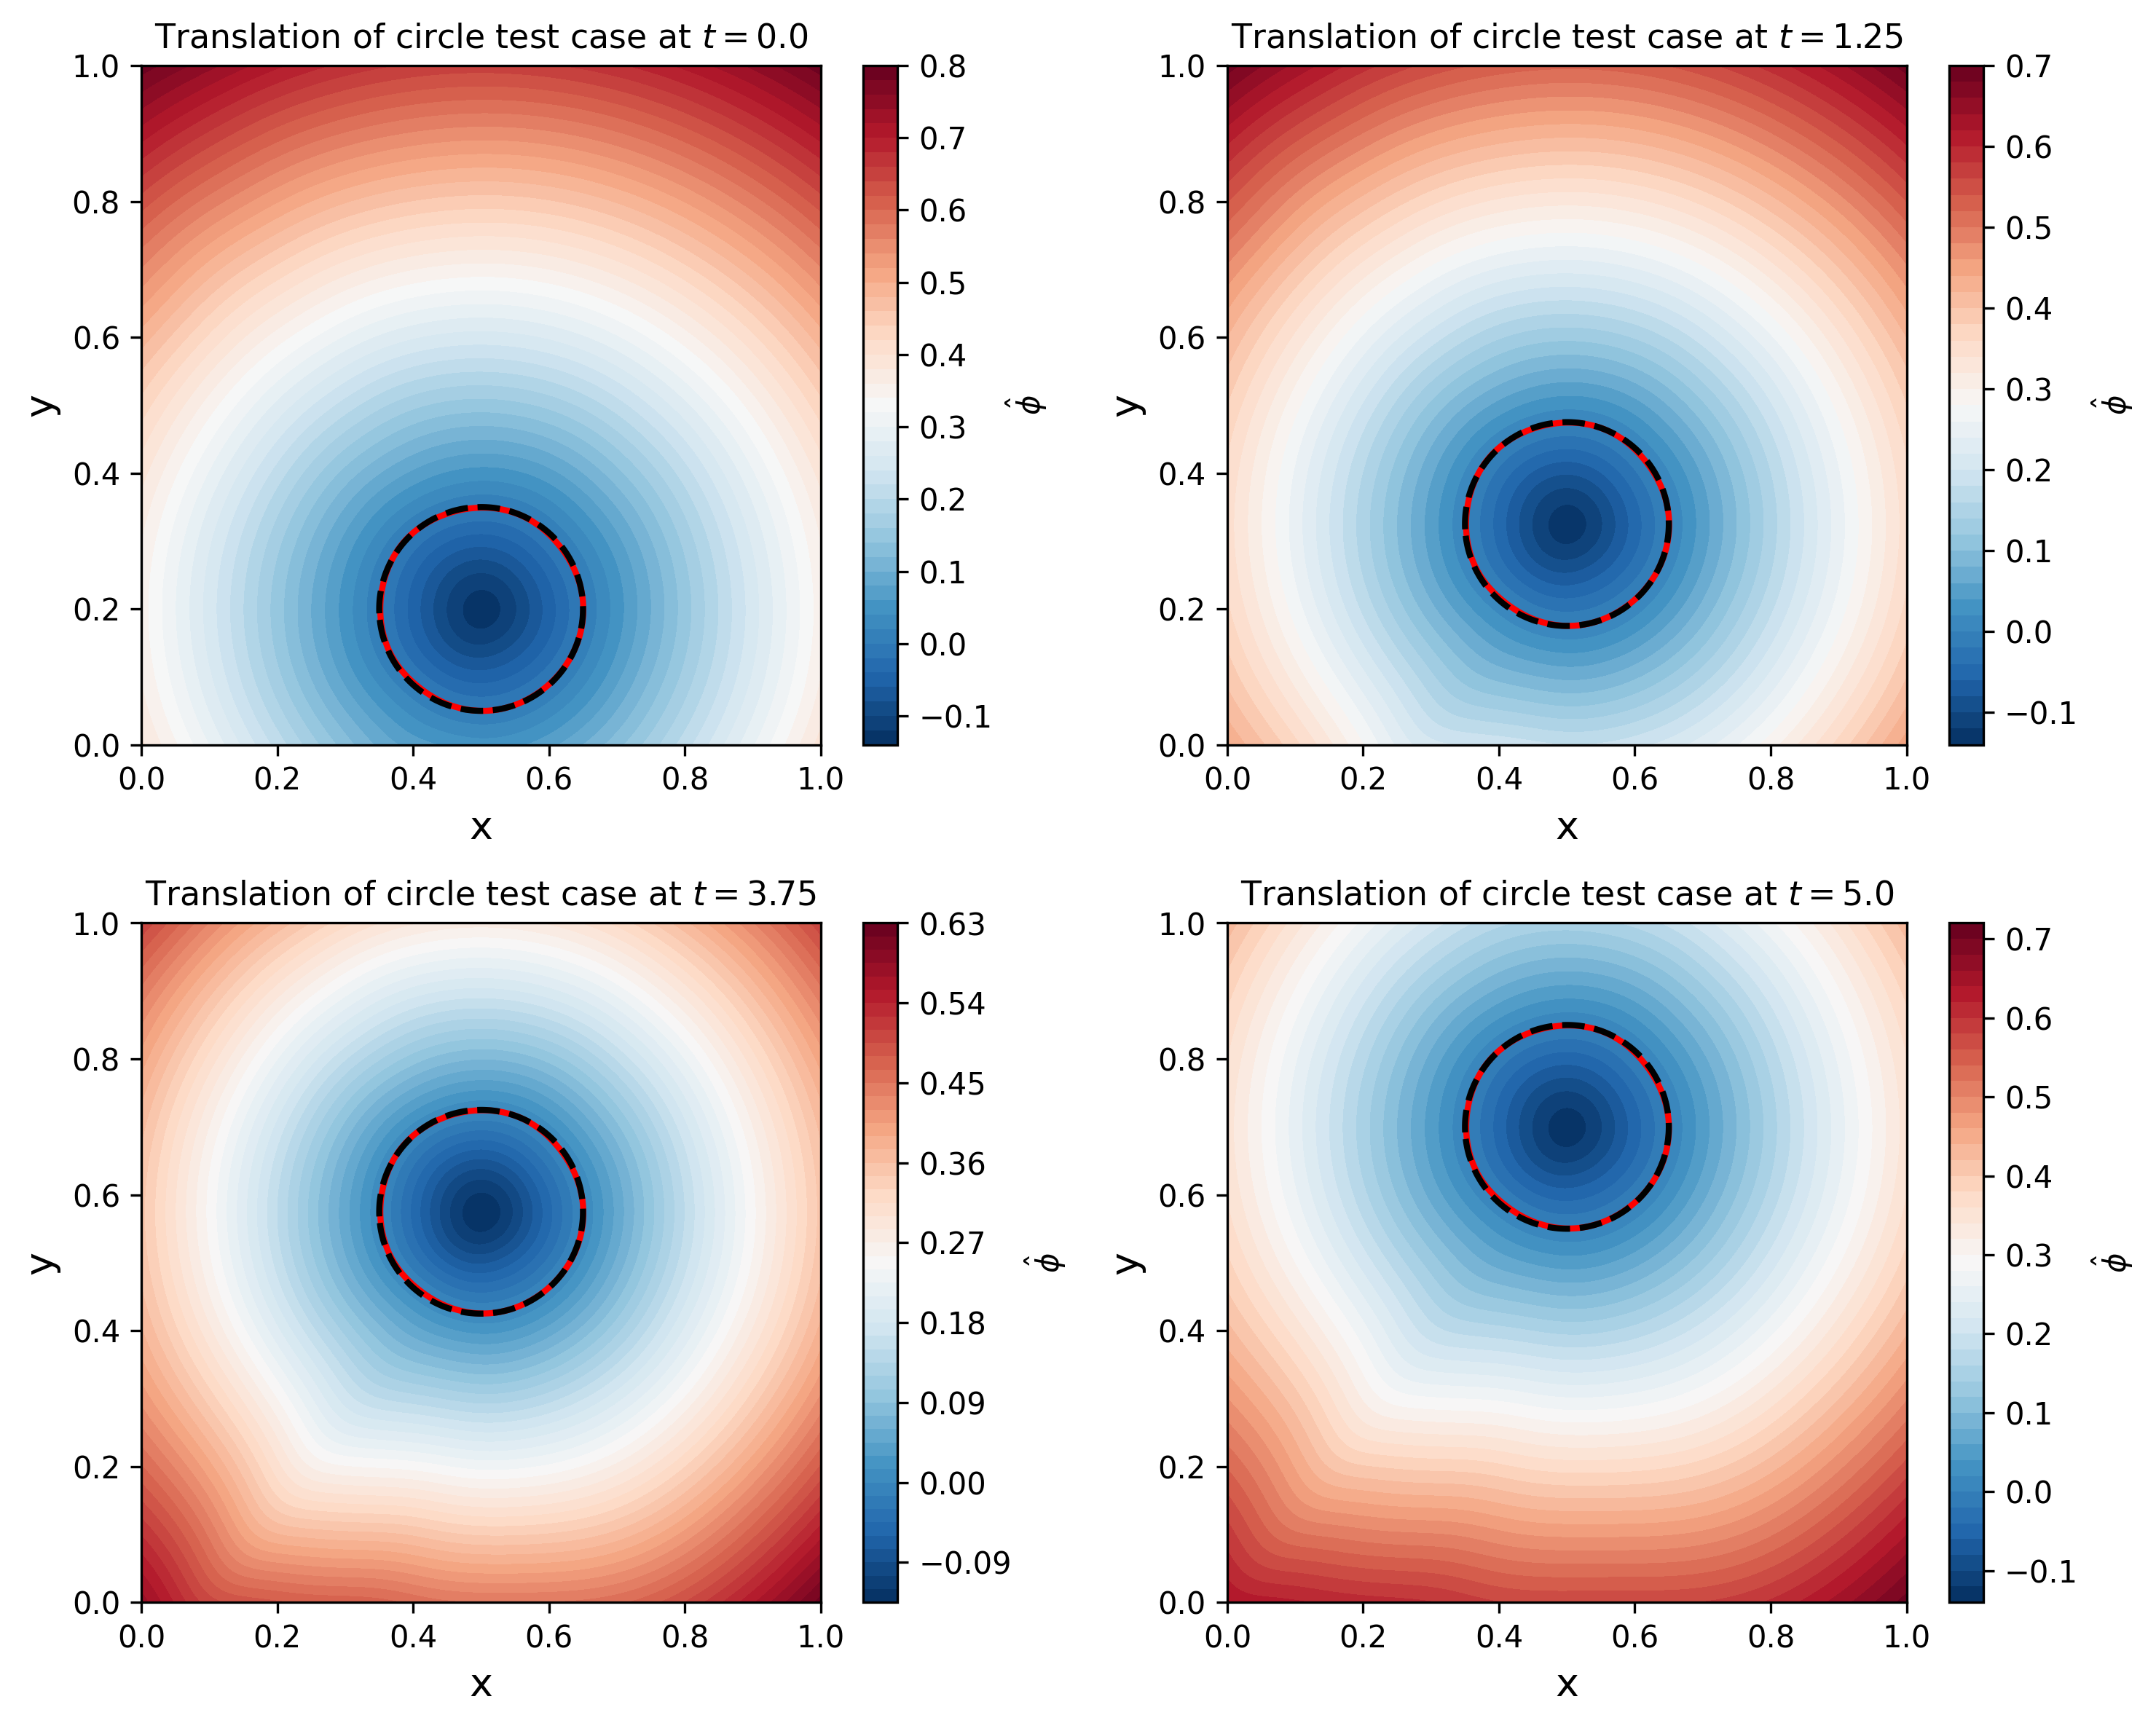


Snapshot           abs L2   rel L2 (%)     Mass err
--------------------------------------------------
t=0.00          7.52e-04        0.20%      8.61e-04
t=1.25          2.12e-03        0.68%      7.72e-04
t=3.75          8.48e-03        3.01%      6.60e-04
t=5.00          1.19e-02        3.69%      9.06e-04
--------------------------------------------------
avg              5.83e-03        1.90%      8.00e-04


In [3]:
# ========================
# Evaluation
# ========================
import matplotlib.pyplot as plt

nx, ny = 300, 300
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y, indexing='ij')
dx = x[1] - x[0]
dy = y[1] - y[0]

times = [0.0, T_final/4, 3*T_final/4, T_final]
l2_errors = []
l2_rel_errors = []
mass_errors = []

fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=300)

for ax, t_val in zip(axes.flat, times):

    t_norm = t_val / T_final

    XYT = torch.tensor(
        np.stack([
            X.flatten(),
            Y.flatten(),
            t_norm * np.ones_like(X.flatten())
        ], axis=1),
        dtype=torch.float32,
        device=device
    )

    with torch.no_grad():
        phi_pred = model(XYT).cpu().numpy().reshape(nx, ny)

    x_tensor = torch.tensor(X.flatten(), dtype=torch.float32).reshape(-1, 1)
    y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32).reshape(-1, 1)
    phi_true = exact_solution(
        x_tensor,
        y_tensor,
        t_val
    ).numpy().reshape(nx, ny)

    # errors
    l2_error   = np.sqrt(np.mean((phi_pred - phi_true)**2))
    l2_rel     = np.sqrt(np.sum((phi_pred - phi_true)**2)) / np.sqrt(np.sum(phi_true**2)) * 100
    mass_pred  = np.sum(phi_pred < 0) * dx * dy
    mass_true  = np.sum(phi_true < 0) * dx * dy
    mass_error = abs(mass_pred - mass_true)

    l2_errors.append(l2_error)
    l2_rel_errors.append(l2_rel)
    mass_errors.append(mass_error)

    countf = ax.contourf(X, Y, phi_pred, levels=50, cmap='RdBu_r')
    ax.contour(X, Y, phi_pred, levels=[0], colors='red',   linewidths=2)
    ax.contour(X, Y, phi_true, levels=[0], colors='black', linewidths=2, linestyles='--')
    ax.set_title(f'Translation of circle test case at $t={t_val}$', fontsize=11)
    ax.set_xlabel('x', fontsize=13)
    ax.set_ylabel('y', fontsize=13)
    ax.set_aspect('equal')
    plt.colorbar(countf, ax=ax, label=r'$\hat{\phi}$')

plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Snapshot':<12} {'abs L2':>12} {'rel L2 (%)':>12} {'Mass err':>12}")
print('-' * 50)
for t_val, l2a, l2r, me in zip(times, l2_errors, l2_rel_errors, mass_errors):
    print(f't={t_val:<8.2f}  {l2a:>12.2e}  {l2r:>10.2f}%  {me:>12.2e}')
print('-' * 50)
print(f"{'avg':<12} {np.mean(l2_errors):>12.2e}  {np.mean(l2_rel_errors):>10.2f}%  {np.mean(mass_errors):>12.2e}")

In [4]:
import csv

# CONFIG
EXP_ID           = 'TR_S2_exp02'
BENCHMARK        = 'TR'
SAMPLING         = 'uniform'
SCHEDULER        = 'StepLR'
SCHEDULER_PARAMS = 'step_1000_gamma_0.9'
T_NORMALIZED     = True
CSV_PATH         = '/content/drive/MyDrive/TR_S2_eikonal_study.csv'

row = {
    'exp_id':            EXP_ID,
    'benchmark':         BENCHMARK,
    'N_f':               N_f,
    'N_i':               N_i,
    'layers':            LAYERS,
    'neurons':           NEURONS,
    'w_pde':             w_pde,
    'w_ic':              w_ic,
    'w_eik':             w_eik,
    'adam_epochs':       adam_epochs,
    'lbfgs_epochs':      lbfgs_epochs,
    'scheduler':         SCHEDULER,
    'scheduler_params':  SCHEDULER_PARAMS,
    'sampling':          SAMPLING,
    't_normalized':      T_NORMALIZED,
    # abs L2 per snapshot
    'L2abs_t0':          f'{l2_errors[0]:.2e}',
    'L2abs_tT4':         f'{l2_errors[1]:.2e}',
    'L2abs_t3T4':        f'{l2_errors[2]:.2e}',
    'L2abs_tT':          f'{l2_errors[3]:.2e}',
    'avg_L2abs':         f'{np.mean(l2_errors):.2e}',
    # rel L2 (%) per snapshot
    'L2rel(%)_t0':       f'{l2_rel_errors[0]:.2f}%',
    'L2rel(%)_tT4':      f'{l2_rel_errors[1]:.2f}%',
    'L2rel(%)_t3T4':     f'{l2_rel_errors[2]:.2f}%',
    'L2rel(%)_tT':       f'{l2_rel_errors[3]:.2f}%',
    'avg_L2rel(%)':      f'{np.mean(l2_rel_errors):.2f}%',
    # mass error per snapshot
    'mass_t0':           f'{mass_errors[0]:.2e}',
    'mass_tT4':          f'{mass_errors[1]:.2e}',
    'mass_t3T4':         f'{mass_errors[2]:.2e}',
    'mass_tT':           f'{mass_errors[3]:.2e}',
    'avg_mass':          f'{np.mean(mass_errors):.2e}',
    'training_time':     checkpoint['training_time'],
}

write_header = False
try:
    with open(CSV_PATH, 'r') as f:
        write_header = (f.read(1) == '')
except FileNotFoundError:
    write_header = True

with open(CSV_PATH, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=row.keys())
    if write_header:
        writer.writeheader()
    writer.writerow(row)

print(f'Row appended → {CSV_PATH}')

Row appended → /content/drive/MyDrive/TR_S2_eikonal_study.csv
